## Atividade de Probabilidade

**Pontuação:** Esta atividade vale **2 pontos** para a primeira unidade da disciplina.

**OBS:** TODAS AS QUESTÕES DEVEM TER SUAS RESPOSTAS JUSTIFICADAS

# Grupo:
- Leandro Simon
- Filipe Oliveira
- José Bruno
- Gibson Rocha

In [1]:
# Bibliotecas Necessárias
# Execute esta célula antes de começar a resolver as questões.
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import quad

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


### Questão 1:
Uma empresa de testes médicos desenvolveu um teste para uma doença rara que afeta 0.1% da população. O teste tem uma taxa de acerto de 99% para pessoas doentes (sensibilidade) e uma taxa de 95% para pessoas saudáveis (especificidade, ou seja, $P(\text{negativo}|\text{saudável})$). Se uma pessoa testa positivo, qual é a probabilidade de ela realmente ter a doença?

In [8]:
# Probabilidades dadas
P_doenca = 0.001  # Prevalência da doença
P_saudavel = 1 - P_doenca  # Probabilidade de saudável
P_pos_doenca = 0.99  # Sensibilidade
P_pos_saudavel = 0.05  # 1 - Especificidade (P(negativo|saudável) = 0.95, então P(positivo|saudável) = 0.05)

# Probabilidade total de teste positivo
P_positivo = (P_pos_doenca * P_doenca) + (P_pos_saudavel * P_saudavel)

# Probabilidade de ter a doença dado positivo
P_doenca_pos = (P_pos_doenca * P_doenca) / P_positivo

print(f"A probabilidade de realmente ter a doença dado teste positivo é: {P_doenca_pos * 100:.2f}%")


A probabilidade de realmente ter a doença dado teste positivo é: 1.94%


### Questão 2: Probabilidade envolvendo Análise Combinatória (Arranjos/Combinações)

Em uma turma de 30 alunos, 18 são mulheres e 12 são homens. Se 3 alunos são selecionados aleatoriamente para formar uma comissão, qual é a probabilidade de que a comissão seja composta por 2 mulheres e 1 homem?

In [12]:
import math

# Função para calcular combinações
def comb(n, k):
    if k > n or k < 0:
        return 0
    return math.comb(n, k)

# Total de alunos: 30
# Mulheres: 18
# Homens: 12
# Selecionar 3 alunos: 2 mulheres e 1 homem

# Número total de maneiras de selecionar 3 alunos
total_de_grupo = comb(30, 3)

# Maneiras favoráveis: escolher 2 mulheres de 18 e 1 homem de 12
eventos_possiveis = comb(18, 2) * comb(12, 1)

# Probabilidade
prob = eventos_possiveis / total_de_grupo

print(f"A probabilidade de a comissão ser composta por 2 mulheres e 1 homem é: {prob * 100:.2f}%")

A probabilidade de a comissão ser composta por 2 mulheres e 1 homem é: 45.22%


### Questão 3: Distribuição de Bernoulli (com geração de gráfico de barras da distribuição)

Em experimento consiste em jogar uma moeda viciada onde a probabilidade de sair cara é 0.6. Defina a distribuição de Bernoulli para este experimento e calcule a probabilidade de sair cara e de sair coroa. Em seguida, utilize `matplotlib.pyplot.bar()` para visualizar a PMF (Função Massa de Probabilidade) desta distribuição.

P(cara) = 0.60
P(coroa) = 0.40


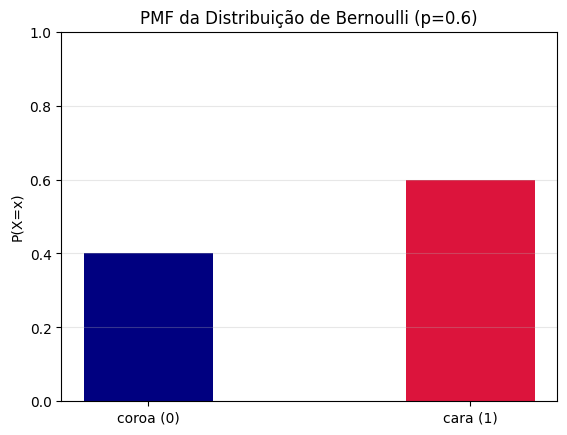

In [13]:
p_cara = 0.6
p_coroa = 1 - p_cara

# valores de X: 1=cara, 0=coroa
x = np.array([0, 1])
pmf = np.array([p_coroa, p_cara])

print(f"P(cara) = {p_cara:.2f}")
print(f"P(coroa) = {p_coroa:.2f}")

# Gráfico da PMF
plt.figure()
plt.bar(x, pmf, width=0.4, color=['navy', 'crimson'])
plt.xticks(x, ['coroa (0)', 'cara (1)'])
plt.ylabel('P(X=x)')
plt.title('PMF da Distribuição de Bernoulli (p=0.6)')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.show()

### Questão 4: Distribuição Binomial

A **Distribuição Binomial** modela o número de sucessos em uma sequência de $n$ ensaios independentes de Bernoulli, cada um com probabilidade de sucesso $p$. A PMF é dada por:

$$P(X=k) = \binom{n}{k} p^k (1-p)^{n-k}$$


uma pesquisa mostra que 30% dos estudantes universitários usam transporte público. Se selecionarmos aleatoriamente 15 estudantes, qual é a probabilidade de que:

a) Exatamente 5 estudantes usem transporte público?

b) No máximo 3 estudantes usem transporte público (probabilidade acumulada)?

Utilize `scipy.stats.binom` para os cálculos.

c) Plote o gráfico da PMF para $k$ de 0 a 15 usando `plt.stem()`.

In [ ]:
# Questão 4: Distribuição Binomial
# Parâmetros: n=15, p=0.3

n = 15
p = 0.3

# a) Probabilidade de exatamente 5 estudantes usarem transporte público
prob_a = stats.binom.pmf(5, n, p)
print(f"a) P(X=5) = {prob_a:.4f}")

# b) Probabilidade de no máximo 3 estudantes usarem transporte público (P(X <= 3))
prob_b = stats.binom.cdf(3, n, p)
print(f"b) P(X <= 3) = {prob_b:.4f}")

# c) Gráfico da PMF para k de 0 a 15
k_values = np.arange(0, n+1)
pmf_values = stats.binom.pmf(k_values, n, p)

plt.figure()
plt.stem(k_values, pmf_values, basefmt=" ")
plt.xlabel('k')
plt.ylabel('P(X=k)')
plt.title('PMF da Distribuição Binomial (n=15, p=0.3)')
plt.grid(True)
plt.show()

### Questão 5: Esperança Matemática

A **Esperança Matemática** ou **Valor Esperado** $E[X]$ de uma variável aleatória discreta $X$ é a média ponderada de todos os valores possíveis que $X$ pode assumir, onde os pesos são as probabilidades de cada valor. É calculada por:

$$E[X] = \sum_{i} x_i P(X=x_i)$$



Considere um jogo onde você lança um dado justo de 6 faces. Se sair um número par, você ganha o valor do número em reais (ex: 2, 4, 6 reais). Se sair um número ímpar, você perde 3 reais. Qual é a esperança matemática do seu ganho/perda neste jogo?

In [3]:
valores = np.array([
    -3,  # Se sair 1 (ímpar)
     2,  # Se sair 2 (par)
    -3,  # Se sair 3 (ímpar)
     4,  # Se sair 4 (par)
    -3,  # Se sair 5 (ímpar)
     6   # Se sair 6 (par)
])

# Probabilidade de cada face = 1/6
probabilidades = np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])

# Esperança Matemática E[X] = Σ xi * P(X = xi)
esperanca = np.sum(valores * probabilidades)

print(f"Valores possíveis: {valores}")
print(f"Probabilidades: {probabilidades}")
print(f"Esperança Matemática do ganho/perda: R$ {esperanca:.2f}")

if esperanca > 0:
    print(f"O jogo é favorável ao jogador (ganho esperado de R$ {esperanca:.2f})")
elif esperanca < 0:
    print(f"O jogo é desfavorável ao jogador (perda esperada de R$ {abs(esperanca):.2f})")
else:
    print("O jogo é justo (esperança nula)")


Valores possíveis: [-3  2 -3  4 -3  6]
Probabilidades: [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
Esperança Matemática do ganho/perda: R$ 0.50
O jogo é favorável ao jogador (ganho esperado de R$ 0.50)


### Questão 6: Distribuição Exponencial Contínua
A **Distribuição Exponencial** é uma distribuição de probabilidade contínua que descreve o tempo entre eventos em um processo de Poisson, ou seja, eventos que ocorrem continuamente e independentemente a uma taxa média constante. Sua função densidade de probabilidade (PDF) é:

$$f(x; \lambda) = \lambda e^{-\lambda x} \quad \text{para } x \ge 0$$

Onde $\lambda$ é a taxa de ocorrência (inverso da média).

O tempo de vida de um componente eletrônico segue uma distribuição exponencial com uma taxa de falha média de $\lambda = 0.002$ falhas por hora. Qual é a probabilidade de um componente durar mais de 1000 horas? (Ou seja, $P(X > 1000)$).

In [5]:
lambdaa = 0.002
x = 1000

# Usando scipy.stats.expon para calcular P(X > 1000)
# P(X > 1000) = 1 - P(X <= 1000) = 1 - CDF(1000)
prob_maior_que_1000 = 1 - stats.expon.cdf(x, scale=1/lambdaa)

# Ou usando o método de confiabilidade (survival function)
prob_maior_que_1000_sf = stats.expon.sf(x, scale=1/lambdaa)

print(f"Parâmetro λ = {lambdaa} falhas por hora")
print(f"Tempo em horas = {x}")
print(f"P(X > {x}) = {prob_maior_que_1000:.6f}")
print(f"Ou P(X > {x}) = {prob_maior_que_1000_sf:.6f}")
print(f"A probabilidade de um componente durar mais de 1000 horas é: {prob_maior_que_1000*100:.2f}%")

# Validação usando a fórmula direta: P(X > x) = e^(-λx)
prob_formula = np.exp(-lambdaa * x)
print(f"Verificação pela fórmula P(X > x) = e^(-λx) = e^(-{lambdaa}*{x}) = {prob_formula:.6f}")


Parâmetro λ = 0.002 falhas por hora
Tempo em horas = 1000
P(X > 1000) = 0.135335
Ou P(X > 1000) = 0.135335
A probabilidade de um componente durar mais de 1000 horas é: 13.53%
Verificação pela fórmula P(X > x) = e^(-λx) = e^(-0.002*1000) = 0.135335


### Questão 7: Distribuição Contínua de Probabilidade

Dada a função densidade de probabilidade $f(x) = 2x$ para $0 \le x \le 1$ e $f(x) = 0$ caso contrário, utilize a função `quad` do módulo `scipy.integrate` para encontrar a probabilidade de $X > 0.5$.

In [6]:
# Definir a função densidade de probabilidade
def f(x):
    if 0 <= x <= 1:
        return 2 * x
    else:
        return 0

# Calcular P(X > 0.5) usando integração numérica
# P(X > 0.5) = ∫[0.5, 1] f(x) dx
prob_x_maior_05, erro = quad(f, 0.5, 1)

print("Questão 7: Distribuição Contínua de Probabilidade")
print(f"Função densidade de probabilidade: f(x) = 2x para 0 ≤ x ≤ 1")
print(f"P(X > 0.5) = ∫[0.5, 1] 2x dx")
print(f"P(X > 0.5) = {prob_x_maior_05:.6f}")
print(f"Erro de integração: {erro:.2e}")

# Validação analítica
# ∫ 2x dx = x² + C
# ∫[0.5, 1] 2x dx = [x²]₀.₅¹ = 1² - (0.5)² = 1 - 0.25 = 0.75
prob_analitica = 1**2 - 0.5**2
print(f"Verificação pela integração analítica: {prob_analitica:.6f}")
print(f"Resultado: A probabilidade de X > 0.5 é {prob_x_maior_05*100:.2f}%")


Questão 7: Distribuição Contínua de Probabilidade
Função densidade de probabilidade: f(x) = 2x para 0 ≤ x ≤ 1
P(X > 0.5) = ∫[0.5, 1] 2x dx
P(X > 0.5) = 0.750000
Erro de integração: 8.33e-15
Verificação pela integração analítica: 0.750000
Resultado: A probabilidade de X > 0.5 é 75.00%


### Questão 8: Esperança Matemática para uma variável aleatória contínua

Para uma **variável aleatória contínua**, a Esperança Matemática $E[X]$ é calculada pela integral de $x$ vezes sua Função Densidade de Probabilidade (PDF) $f(x)$ sobre todo o domínio de $X$.

$$E[X] = \int_{-\infty}^{\infty} x \cdot f(x) \ dx$$


Usando a mesma função densidade de probabilidade da Questão 7, $f(x) = 2x$ para $0 \le x \le 1$, calcule a esperança matemática $E[X]$ para esta distribuição. Utilize `scipy.integrate.quad`.

In [7]:
# Definir a função densidade de probabilidade
def f(x):
    if 0 <= x <= 1:
        return 2 * x
    else:
        return 0

# Definir a função para o integrando de E[X]: x * f(x)
def integrando_ex(x):
    return x * f(x)

# Calcular E[X] usando integração numérica
esperanca_x, erro = quad(integrando_ex, 0, 1)

print(f"Função densidade de probabilidade: f(x) = 2x para 0 ≤ x ≤ 1")
print(f"E[X] = ∫[0,1] x * f(x) dx = ∫[0,1] 2x² dx")
print(f"E[X] = {esperanca_x:.6f}")
print(f"Erro de integração: {erro:.2e}")

# Validação analítica
# ∫ 2x² dx = (2/3)x³ + C
# ∫[0,1] 2x² dx = [(2/3)x³]₀¹ = (2/3)(1)³ - (2/3)(0)³ = 2/3 ≈ 0.666667
esperanca_analitica = 2/3
print(f"Verificação pela integração analítica: {esperanca_analitica:.6f}")
print(f"Resultado: A esperança matemática E[X] é {esperanca_x:.4f}")


Função densidade de probabilidade: f(x) = 2x para 0 ≤ x ≤ 1
E[X] = ∫[0,1] x * f(x) dx = ∫[0,1] 2x² dx
E[X] = 0.666667
Erro de integração: 7.40e-15
Verificação pela integração analítica: 0.666667
Resultado: A esperança matemática E[X] é 0.6667


### Questão 9: Variância e Desvio Padrão em contextos de distribuições contínuas

A **Variância** $\text{Var}(X)$ e o **Desvio Padrão** $\sigma_X$ medem a dispersão de uma variável aleatória. Para uma variável aleatória contínua, a variância é calculada como:

$$\text{Var}(X) = E[X^2] - (E[X])^2$$

Onde $E[X^2] = \int_{-\infty}^{\infty} x^2 \cdot f(x) \ dx$.
O Desvio Padrão é $\sigma_X = \sqrt{\text{Var}(X)}$.


Para a função densidade de probabilidade $f(x) = 2x$ para $0 \le x \le 1$ (usada nas Questões 7 e 8), calcule a variância e o desvio padrão. Você já calculou $E[X]$ na questão anterior; agora você precisará calcular $E[X^2]$ usando `scipy.integrate.quad`.

In [9]:
# Definir a função densidade de probabilidade
def f(x):
    if 0 <= x <= 1:
        return 2 * x
    else:
        return 0

# Definir a função para o integrando de E[X²]: x² * f(x)
def integrando_ex2(x):
    return x**2 * f(x)

# Calcular E[X²] usando integração numérica
ex2, erro_ex2 = quad(integrando_ex2, 0, 1)

# E[X] da questão anterior (calculado analiticamente como 2/3)
ex = 2/3

# Calcular a variância
variancia = ex2 - ex**2

# Calcular o desvio padrão
desvio_padrao = np.sqrt(variancia)

print(f"Função densidade de probabilidade: f(x) = 2x para 0 ≤ x ≤ 1")
print(f"E[X²] = ∫[0,1] x² * f(x) dx = ∫[0,1] 2x³ dx")
print(f"E[X²] = {ex2:.6f} (erro: {erro_ex2:.2e})")
print(f"E[X] = {ex:.6f}")
print(f"Var(X) = E[X²] - (E[X])² = {variancia:.6f}")
print(f"Desvio Padrão σ = √(Var(X)) = {desvio_padrao:.6f}")

# Validação analítica
# E[X²] = ∫[0,1] 2x³ dx = [(1/2)x⁴]₀¹ = 1/2 = 0.5
# Var(X) = 0.5 - (2/3)² = 0.5 - 4/9 = 1/18 ≈ 0.055556
# σ = √(1/18) = 1/√18 ≈ 0.333333
ex2_analitica = 1/2
variancia_analitica = 1/18
desvio_padrao_analitica = 1/np.sqrt(18)
print(f"Verificação analítica:")
print(f"E[X²] = {ex2_analitica:.2f}")
print(f"Var(X) = {variancia_analitica:.4f}")
print(f"Desvio Padrão σ = {desvio_padrao_analitica:.4f}")


Função densidade de probabilidade: f(x) = 2x para 0 ≤ x ≤ 1
E[X²] = ∫[0,1] x² * f(x) dx = ∫[0,1] 2x³ dx
E[X²] = 0.500000 (erro: 5.55e-15)
E[X] = 0.666667
Var(X) = E[X²] - (E[X])² = 0.055556
Desvio Padrão σ = √(Var(X)) = 0.235702
Verificação analítica:
E[X²] = 0.50
Var(X) = 0.0556
Desvio Padrão σ = 0.2357


### Questão 10: Problema aplicado distribuição Binomial

Em uma grande fábrica, 8% dos produtos são defeituosos. Se um inspetor seleciona aleatoriamente uma amostra de 200 produtos, qual é a probabilidade de que:

a) Menos de 10 produtos na amostra sejam defeituosos?

b) Exatamente 15 produtos na amostra sejam defeituosos?

In [10]:
n = 200
p = 0.08

# a) Probabilidade de menos de 10 produtos serem defeituosos (P(X < 10) = P(X <= 9))
prob_a = stats.binom.cdf(9, n, p)
print(f"a) P(X < 10) = P(X ≤ 9) = {prob_a:.6f}")
print(f"   Ou {prob_a*100:.2f}%")

# b) Probabilidade de exatamente 15 produtos serem defeituosos (P(X = 15))
prob_b = stats.binom.pmf(15, n, p)
print(f"b) P(X = 15) = {prob_b:.6f}")
print(f"   Ou {prob_b*100:.2f}%")

# Informações adicionais
print(f"\nParâmetros da distribuição: n = {n}, p = {p}")
print(f"Número esperado de defeituosos: E[X] = n*p = {n*p:.1f}")
print(f"Variância: Var(X) = n*p*(1-p) = {n*p*(1-p):.1f}")
print(f"Desvio padrão: σ = √(Var(X)) = {np.sqrt(n*p*(1-p)):.2f}")


a) P(X < 10) = P(X ≤ 9) = 0.037371
   Ou 3.74%
b) P(X = 15) = 0.102879
   Ou 10.29%

Parâmetros da distribuição: n = 200, p = 0.08
Número esperado de defeituosos: E[X] = n*p = 16.0
Variância: Var(X) = n*p*(1-p) = 14.7
Desvio padrão: σ = √(Var(X)) = 3.84
